<a href="https://colab.research.google.com/github/jaysulk/hartley-neural-operator/blob/main/HNO_FNO_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, json
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    SAVE_DIR = '/content/drive/MyDrive/TLMR_HNO_experiments'
except Exception:
    SAVE_DIR = os.environ.get('SAVE_DIR', '.')

FIG_DIR = os.path.join(SAVE_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300, 'font.size': 9})

print('SAVE_DIR   =', SAVE_DIR)
print('fields dir :', os.path.join(SAVE_DIR, 'fields'),
      '->', 'found' if os.path.isdir(os.path.join(SAVE_DIR, 'fields')) else 'MISSING')

Mounted at /content/drive
SAVE_DIR   = /content/drive/MyDrive/TLMR_HNO_experiments
fields dir : /content/drive/MyDrive/TLMR_HNO_experiments/fields -> found


In [2]:
# ---- labels / ordering / theory prediction ----
PDES = ['heat','wave','burgers','navier_stokes','advection_diffusion','poisson','biharmonic']
ICS  = ['eigenfunction','grf','gaussian_bump']
BCS  = ['periodic','dirichlet']
ELLIPTIC = {'poisson','biharmonic'}

PDE_LABEL = {'heat':'Heat','wave':'Wave','burgers':'Burgers','navier_stokes':'Navier-Stokes',
             'advection_diffusion':'Adv-Diff','poisson':'Poisson','biharmonic':'Biharmonic'}
IC_LABEL = {'eigenfunction':'Eigen','grf':'GRF','gaussian_bump':'Bump'}
BC_LABEL = {'periodic':'Per','dirichlet':'Dir'}

def predicted(pde): return 'HNO' if pde in ELLIPTIC else 'FNO'

COLS = [(ic, bc) for ic in ICS for bc in BCS]          # 6 columns, IC-major
COL_LABEL = [IC_LABEL[ic] + '/' + BC_LABEL[bc] for ic, bc in COLS]

BEST_BY = 'ratio'

In [3]:
import glob

FDIR = os.path.join(SAVE_DIR, 'fields')
print('fields dir:', FDIR, '| exists:', os.path.isdir(FDIR))

agg = defaultdict(lambda: defaultdict(list))
per_seed = defaultdict(list)
nfiles = 0
for p in sorted(glob.glob(os.path.join(FDIR, '*.npz'))):
    parts = os.path.basename(p)[:-4].split('__')
    if len(parts) != 4:
        print('  ?? cannot parse filename:', os.path.basename(p)); continue
    pde, bc, ic, sseed = parts
    try:
        seed = int(sseed.lstrip('s'))
    except Exception:
        seed = 0
    try:
        d = np.load(p)
        fl, hl = float(d['fno_l2']), float(d['hno_l2'])
    except Exception as e:
        print('  skip (bad npz):', os.path.basename(p), '->', e); continue
    k = (pde, bc, ic)
    agg[k]['fno'].append(fl); agg[k]['hno'].append(hl)
    if 'fno_l1' in d.files: agg[k]['fno_l1'].append(float(d['fno_l1']))
    if 'hno_l1' in d.files: agg[k]['hno_l1'].append(float(d['hno_l1']))
    per_seed[k].append(dict(seed=seed, fno=fl, hno=hl, ratio=hl / (fl + 1e-12)))
    nfiles += 1

R = {}
for k, d in agg.items():
    fno, hno = float(np.mean(d['fno'])), float(np.mean(d['hno']))
    R[k] = dict(fno=fno, hno=hno,
                fno_std=float(np.std(d['fno'])), hno_std=float(np.std(d['hno'])),
                ratio=hno / (fno + 1e-12),
                nseeds=len(d['fno']),
                per_seed=sorted(per_seed[k], key=lambda e: e['seed']))

print(f'loaded {nfiles} field files -> {len(R)} unique (pde,bc,ic) cells')

def pick_best(k):
    """Return the per-seed record selected by BEST_BY (lower is better for all metrics)."""
    ps = R[k]['per_seed']
    key = {'ratio': lambda e: e['ratio'], 'hno_l2': lambda e: e['hno'],
           'fno_l2': lambda e: e['fno']}.get(BEST_BY, lambda e: e['ratio'])
    return min(ps, key=key)

def get_field(pde, bc, ic, seed=0):
    p = os.path.join(FDIR, f'{pde}__{bc}__{ic}__s{seed}.npz')
    if not os.path.exists(p):
        cands = sorted(glob.glob(os.path.join(FDIR, f'{pde}__{bc}__{ic}__s*.npz')))
        if not cands: return None
        p = cands[0]                              # fall back to any available seed
    d = np.load(p)
    return {k: d[k] for k in d.files}

for pde in PDES:
    cs = [ic + '/' + bc + (f'(x{R[(pde,bc,ic)]["nseeds"]})' if R[(pde,bc,ic)]['nseeds'] > 1 else '')
          for ic in ICS for bc in BCS if (pde, bc, ic) in R]
    if cs: print('  %-20s %s' % (pde, cs))

fields dir: /content/drive/MyDrive/TLMR_HNO_experiments/fields | exists: True
loaded 126 field files -> 42 unique (pde,bc,ic) cells
  heat                 ['eigenfunction/periodic(x3)', 'eigenfunction/dirichlet(x3)', 'grf/periodic(x3)', 'grf/dirichlet(x3)', 'gaussian_bump/periodic(x3)', 'gaussian_bump/dirichlet(x3)']
  wave                 ['eigenfunction/periodic(x3)', 'eigenfunction/dirichlet(x3)', 'grf/periodic(x3)', 'grf/dirichlet(x3)', 'gaussian_bump/periodic(x3)', 'gaussian_bump/dirichlet(x3)']
  burgers              ['eigenfunction/periodic(x3)', 'eigenfunction/dirichlet(x3)', 'grf/periodic(x3)', 'grf/dirichlet(x3)', 'gaussian_bump/periodic(x3)', 'gaussian_bump/dirichlet(x3)']
  navier_stokes        ['eigenfunction/periodic(x3)', 'eigenfunction/dirichlet(x3)', 'grf/periodic(x3)', 'grf/dirichlet(x3)', 'gaussian_bump/periodic(x3)', 'gaussian_bump/dirichlet(x3)']
  advection_diffusion  ['eigenfunction/periodic(x3)', 'eigenfunction/dirichlet(x3)', 'grf/periodic(x3)', 'grf/dirichlet(

In [4]:
# ---- ratio dump + win tally ----
print('HNO/FNO relative-L2 ratio  (<1 = HNO wins):')
hwin = total = 0
for pde in PDES:
    for ic, bc in COLS:
        k = (pde, bc, ic)
        if k in R:
            rr = R[k]['ratio']; total += 1; hwin += (rr < 1)
            tag = 'HNO' if rr < 1 else 'FNO'
            seedinfo = f"  (x{R[k]['nseeds']} seeds)" if R[k]['nseeds'] > 1 else ''
            print('  %-20s %-13s %-9s  %5.2fx  -> %s%s' % (pde, ic, bc, rr, tag, seedinfo))
if total:
    print(f'\nHNO wins {hwin}/{total} cells overall')

HNO/FNO relative-L2 ratio  (<1 = HNO wins):
  heat                 eigenfunction periodic    1.05x  -> FNO  (x3 seeds)
  heat                 eigenfunction dirichlet   1.24x  -> FNO  (x3 seeds)
  heat                 grf           periodic    1.16x  -> FNO  (x3 seeds)
  heat                 grf           dirichlet   1.20x  -> FNO  (x3 seeds)
  heat                 gaussian_bump periodic    1.01x  -> FNO  (x3 seeds)
  heat                 gaussian_bump dirichlet   1.02x  -> FNO  (x3 seeds)
  wave                 eigenfunction periodic    1.08x  -> FNO  (x3 seeds)
  wave                 eigenfunction dirichlet   1.50x  -> FNO  (x3 seeds)
  wave                 grf           periodic    1.31x  -> FNO  (x3 seeds)
  wave                 grf           dirichlet   1.34x  -> FNO  (x3 seeds)
  wave                 gaussian_bump periodic    1.22x  -> FNO  (x3 seeds)
  wave                 gaussian_bump dirichlet   1.33x  -> FNO  (x3 seeds)
  burgers              eigenfunction periodic    1.59x  

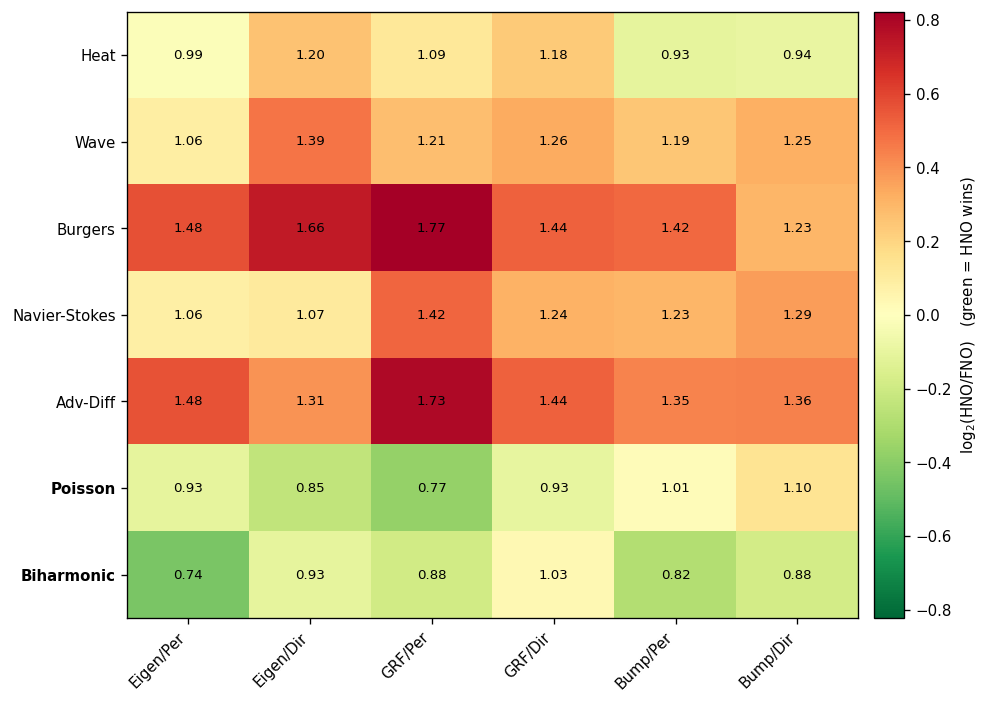

In [5]:
# ---- FIGURE 1: ratio heatmap (PDE x [IC/BC]) -- BEST seed per cell ----
def plot_ratio_heatmap(use_best=True, save=True):
    M = np.full((len(PDES), len(COLS)), np.nan)
    for i, pde in enumerate(PDES):
        for j, (ic, bc) in enumerate(COLS):
            k = (pde, bc, ic)
            if k in R: M[i, j] = pick_best(k)['ratio'] if use_best else R[k]['ratio']
    if np.all(np.isnan(M)): print('no data for heatmap'); return
    L = np.log2(M)
    vmax = max(0.3, float(np.nanmax(np.abs(L))))
    cmap = plt.get_cmap('RdYlGn_r').copy(); cmap.set_bad('0.92')
    fig, ax = plt.subplots(figsize=(1.05*len(COLS)+2.0, 0.62*len(PDES)+1.6))
    im = ax.imshow(np.ma.masked_invalid(L), cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    for i in range(len(PDES)):
        for j in range(len(COLS)):
            if not np.isnan(M[i, j]):
                ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=8)
    ax.set_xticks(range(len(COLS))); ax.set_xticklabels(COL_LABEL, rotation=45, ha='right')
    ax.set_yticks(range(len(PDES))); ax.set_yticklabels([PDE_LABEL[p] for p in PDES])
    for i, pde in enumerate(PDES):
        if pde in ELLIPTIC: ax.get_yticklabels()[i].set_fontweight('bold')
    cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cb.set_label('log$_2$(HNO/FNO)   (green = HNO wins)')
    sub = f'best seed by {BEST_BY}' if use_best else 'mean over seeds'
    #ax.set_title(f'HNO / FNO relative-$L^2$ ratio  ({sub}; bold rows = elliptic)',
                 #fontweight='bold', fontsize=10)
    plt.tight_layout()
    if save: plt.savefig(os.path.join(FIG_DIR, 'ratio_heatmap.pdf'), bbox_inches='tight')
    plt.show()

plot_ratio_heatmap()

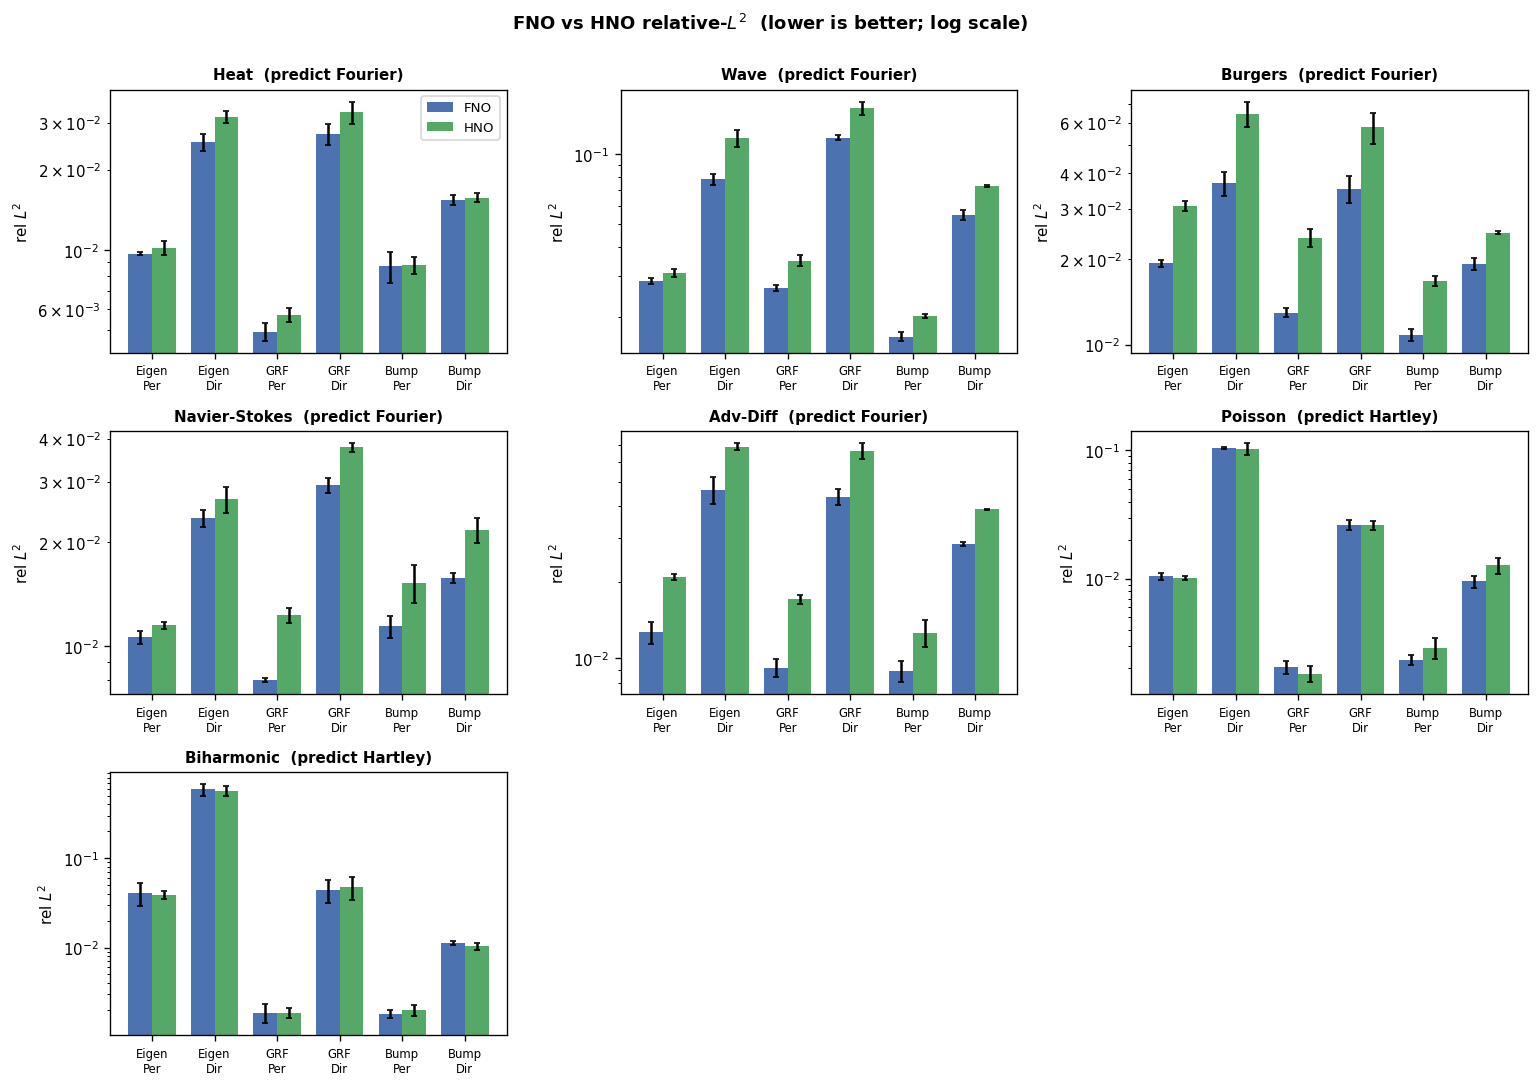

In [6]:
# ---- FIGURE 2: FNO vs HNO bar charts, faceted by PDE ----
def plot_bars(save=True):
    pdes = [p for p in PDES if any((p, bc, ic) in R for ic, bc in COLS)]
    if not pdes: print('no data for bars'); return
    ncol = min(3, len(pdes)); nrow = int(np.ceil(len(pdes)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.3*ncol, 3.0*nrow), squeeze=False)
    for idx, pde in enumerate(pdes):
        ax = axes[idx//ncol][idx % ncol]
        cells = [(ic, bc) for ic, bc in COLS if (pde, bc, ic) in R]
        x = np.arange(len(cells)); w = 0.38
        fno = [R[(pde, bc, ic)]['fno'] for ic, bc in cells]
        hno = [R[(pde, bc, ic)]['hno'] for ic, bc in cells]
        fe  = [R[(pde, bc, ic)]['fno_std'] for ic, bc in cells]
        he  = [R[(pde, bc, ic)]['hno_std'] for ic, bc in cells]
        ax.bar(x - w/2, fno, w, yerr=fe, capsize=2, label='FNO', color='#4C72B0')
        ax.bar(x + w/2, hno, w, yerr=he, capsize=2, label='HNO', color='#55A868')
        ax.set_yscale('log')
        ax.set_xticks(x)
        ax.set_xticklabels([IC_LABEL[ic] + '\n' + BC_LABEL[bc] for ic, bc in cells], fontsize=7)
        pr = 'Hartley' if pde in ELLIPTIC else 'Fourier'
        ax.set_title(f'{PDE_LABEL[pde]}  (predict {pr})', fontsize=9, fontweight='bold')
        ax.set_ylabel('rel $L^2$')
        if idx == 0: ax.legend(fontsize=8)
    for j in range(len(pdes), nrow*ncol): axes[j//ncol][j % ncol].axis('off')
    fig.suptitle('FNO vs HNO relative-$L^2$  (lower is better; log scale)', fontweight='bold', y=1.0)
    plt.tight_layout()
    if save: plt.savefig(os.path.join(FIG_DIR, 'bars.pdf'), bbox_inches='tight')
    plt.show()

plot_bars()

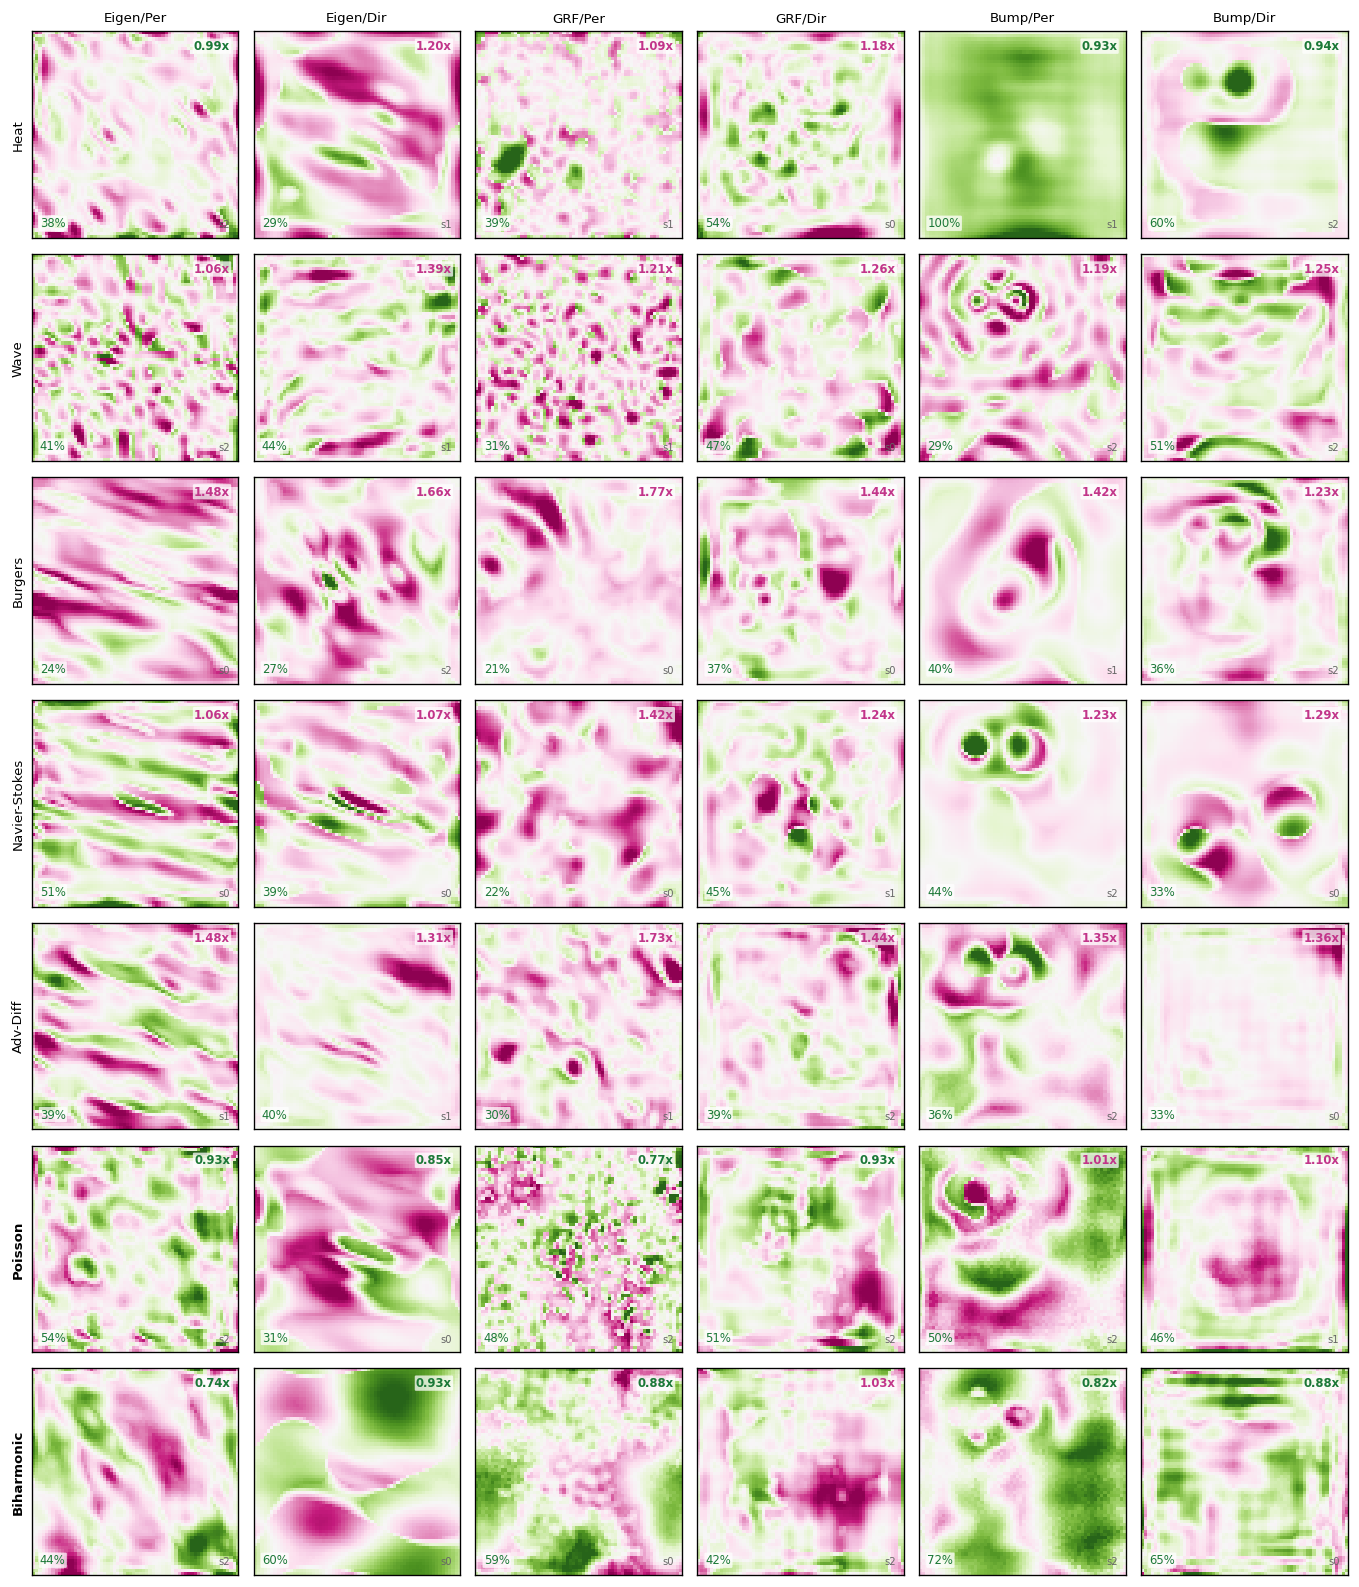

In [7]:
# ---- FIGURE 3: multi-panel spatial error-advantage grid -- BEST seed per cell ----
def plot_error_grid(seed=None, pct=99, save=True):
    nrow, ncol = len(PDES), len(COLS)
    fig, axes = plt.subplots(nrow, ncol, figsize=(1.9*ncol, 1.9*nrow), squeeze=False)
    cmap = plt.get_cmap('PiYG')
    any_data = False
    for i, pde in enumerate(PDES):
        for j, (ic, bc) in enumerate(COLS):
            ax = axes[i][j]; ax.set_xticks([]); ax.set_yticks([])
            k = (pde, bc, ic)
            if seed is None and k in R:
                best = pick_best(k); s = best['seed']; ratio = best['ratio']
            else:
                s = seed if seed is not None else 0; ratio = None
            fd = get_field(pde, bc, ic, s)
            if fd is None:
                ax.set_facecolor('0.94')
                ax.text(0.5, 0.5, '-', ha='center', va='center', transform=ax.transAxes, color='0.6')
            else:
                any_data = True
                tgt, fno, hno = fd['target'], fd['fno'], fd['hno']
                diff = np.abs(tgt - fno) - np.abs(tgt - hno)
                v = float(np.percentile(np.abs(diff), pct)) + 1e-12
                ax.imshow(diff, cmap=cmap, vmin=-v, vmax=v, origin='lower')
                if ratio is None:
                    ratio = float(fd['hno_l2']) / (float(fd['fno_l2']) + 1e-12)
                winpct = 100.0 * float(np.mean(diff > 0))
                rc = '#1b7837' if ratio < 1 else '#c2358a'
                ax.text(0.96, 0.96, f'{ratio:.2f}x', transform=ax.transAxes, ha='right', va='top',
                        fontsize=7, fontweight='bold', color=rc,
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.75))
                ax.text(0.04, 0.04, f'{winpct:.0f}%', transform=ax.transAxes, ha='left', va='bottom',
                        fontsize=7, color='#1b7837',
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.75))
                if seed is None:
                    ax.text(0.96, 0.04, f's{s}', transform=ax.transAxes, ha='right', va='bottom',
                            fontsize=6, color='0.4')
            if i == 0: ax.set_title(COL_LABEL[j], fontsize=8)
            if j == 0:
                ax.set_ylabel(PDE_LABEL[pde], fontsize=8,
                              fontweight=('bold' if pde in ELLIPTIC else 'normal'))
    if not any_data: print('no spatial fields found yet'); plt.close(fig); return
    tag = f'best seed per cell (by {BEST_BY})' if seed is None else f'seed {seed}'
    #fig.suptitle('Spatial error advantage:  |FNO err| - |HNO err|   '
    #             '(green = HNO better, pink = FNO better)\n'
    #             f'top-right = HNO/FNO ratio,  bottom-left = % domain HNO better,  {tag}',
    #             fontsize=10, y=1.004)
    plt.tight_layout()
    if save: plt.savefig(os.path.join(FIG_DIR, 'spatial_error_grid.pdf'), bbox_inches='tight')
    plt.show()

plot_error_grid()

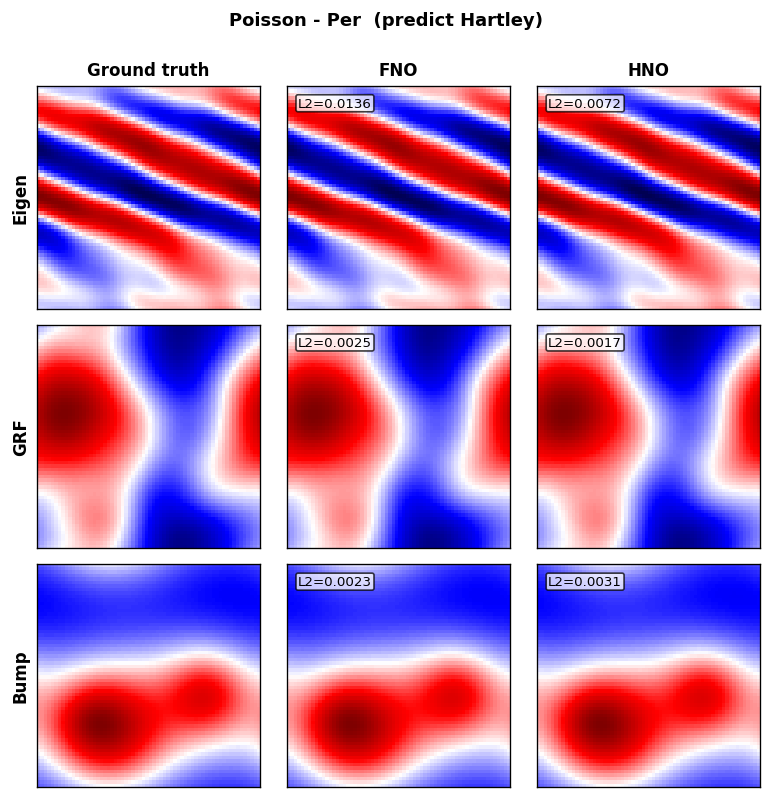

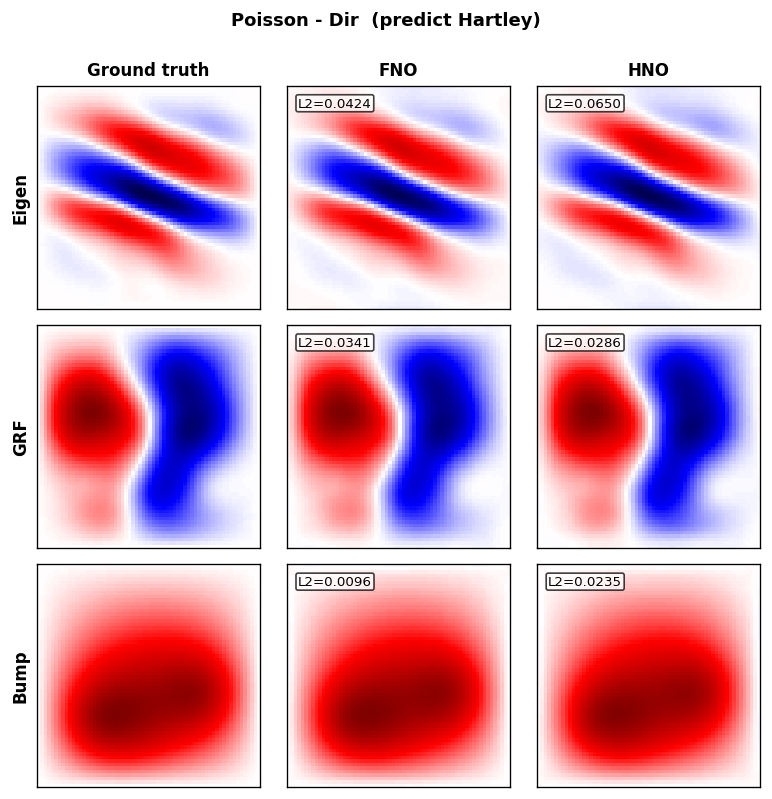

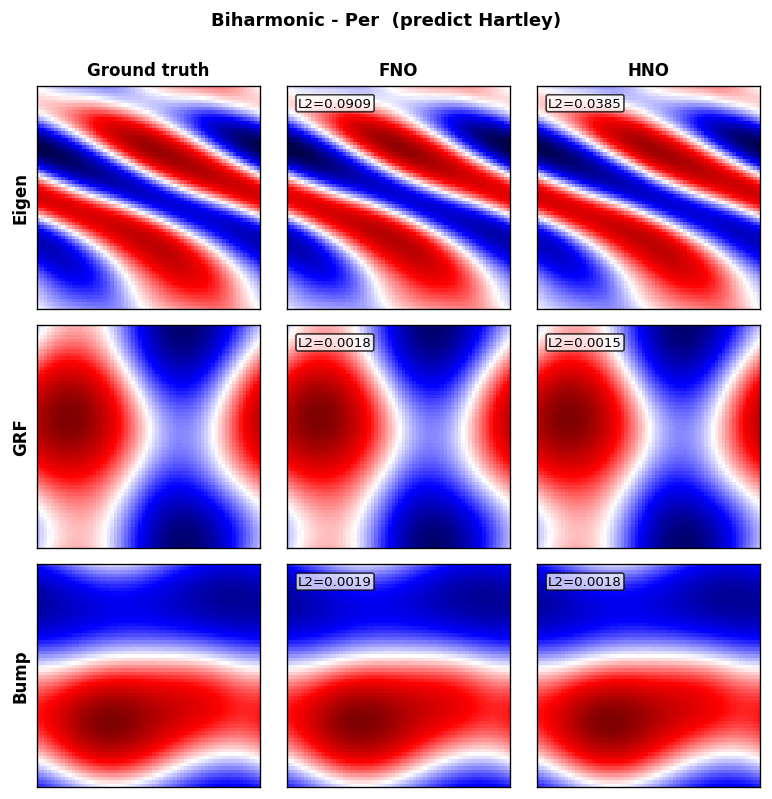

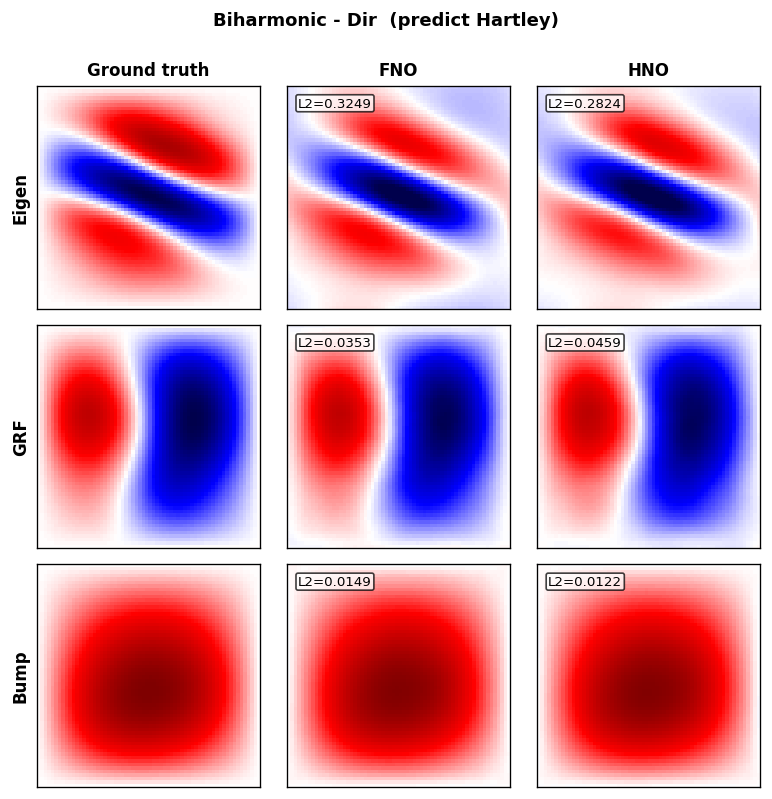

In [8]:
# ---- FIGURE 4: ground-truth / FNO / HNO solution triptychs ----
def plot_solutions(pde, bc, seed=0, save=True):
    cells = [ic for ic in ICS if get_field(pde, bc, ic, seed) is not None]
    if not cells: print('no fields for', pde, bc); return
    nrow = len(cells)
    fig, axes = plt.subplots(nrow, 3, figsize=(3*2.2, nrow*2.2), squeeze=False)
    for i, ic in enumerate(cells):
        fd = get_field(pde, bc, ic, seed)
        tgt, fno, hno = fd['target'], fd['fno'], fd['hno']
        vmax = float(np.abs(tgt).max()) + 1e-12
        nrm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
        for c, (name, arr) in enumerate([('Ground truth', tgt), ('FNO', fno), ('HNO', hno)]):
            ax = axes[i][c]; ax.imshow(arr, cmap='seismic', norm=nrm, origin='lower')
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0: ax.set_title(name, fontsize=10, fontweight='bold')
            if c == 0: ax.set_ylabel(IC_LABEL[ic], fontsize=10, fontweight='bold')
            if c > 0:
                err = float(np.linalg.norm(arr - tgt) / (np.linalg.norm(tgt) + 1e-12))
                ax.text(0.05, 0.95, f'L2={err:.4f}', transform=ax.transAxes, va='top',
                        fontsize=8, bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.75))
    pr = 'Hartley' if pde in ELLIPTIC else 'Fourier'
    fig.suptitle(f'{PDE_LABEL[pde]} - {BC_LABEL[bc]}  (predict {pr})', fontweight='bold', y=1.0)
    plt.tight_layout()
    if save: plt.savefig(os.path.join(FIG_DIR, f'solutions_{pde}_{bc}.pdf'), bbox_inches='tight')
    plt.show()

for pde in ['poisson', 'biharmonic']:
    for bc in ['periodic', 'dirichlet']:
        plot_solutions(pde, bc)

In [9]:
# ---- predicted-vs-observed summary table ----
def summary_table():
    matched = total = 0
    header = '%-15s%-10s%-8s ' % ('PDE', 'class', 'predict') + ' '.join('%11s' % c for c in COL_LABEL)
    print(header); print('-' * len(header))
    for pde in PDES:
        cls = 'elliptic' if pde in ELLIPTIC else 'time-dep'
        pr = predicted(pde)
        cells = []
        for ic, bc in COLS:
            k = (pde, bc, ic)
            if k in R:
                obs = 'HNO' if R[k]['ratio'] < 1 else 'FNO'
                ok = (obs == pr); total += 1; matched += ok
                cells.append(obs + (' OK' if ok else ' x'))
            else:
                cells.append('.')
        print('%-15s%-10s%-8s ' % (PDE_LABEL[pde], cls, pr) + ' '.join('%11s' % c for c in cells))
    if total:
        print('\nprediction matched %d/%d cells (%.0f%%)' % (matched, total, 100 * matched / total))

summary_table()

PDE            class     predict    Eigen/Per   Eigen/Dir     GRF/Per     GRF/Dir    Bump/Per    Bump/Dir
---------------------------------------------------------------------------------------------------------
Heat           time-dep  FNO           FNO OK      FNO OK      FNO OK      FNO OK      FNO OK      FNO OK
Wave           time-dep  FNO           FNO OK      FNO OK      FNO OK      FNO OK      FNO OK      FNO OK
Burgers        time-dep  FNO           FNO OK      FNO OK      FNO OK      FNO OK      FNO OK      FNO OK
Navier-Stokes  time-dep  FNO           FNO OK      FNO OK      FNO OK      FNO OK      FNO OK      FNO OK
Adv-Diff       time-dep  FNO           FNO OK      FNO OK      FNO OK      FNO OK      FNO OK      FNO OK
Poisson        elliptic  HNO           HNO OK      HNO OK      HNO OK      HNO OK       FNO x       FNO x
Biharmonic     elliptic  HNO           HNO OK      HNO OK      HNO OK       FNO x       FNO x      HNO OK

prediction matched 38/42 cells (90%)
